
Sample Data:
      length     width    height  density       label
0  4.061810  2.165500  1.785595      210     vehicle
1  0.598425  0.522916  1.549987       30  pedestrian
2  2.299264  0.800558  1.624844       81     cyclist
3  3.584617  2.005399  1.950842      151     vehicle
4  0.390912  0.391702  1.652121       41  pedestrian

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

     cyclist       1.00      1.00      1.00        26
  pedestrian       1.00      1.00      1.00        30
     vehicle       1.00      1.00      1.00        34

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90


Confusion Matrix:
 [[26  0  0]
 [ 0 30  0]
 [ 0  0 34]]


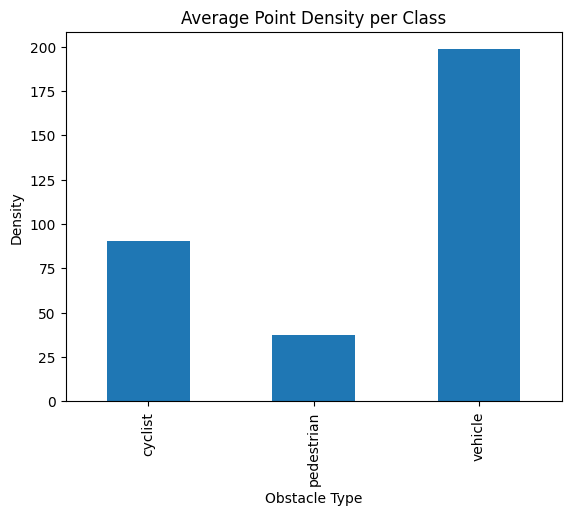

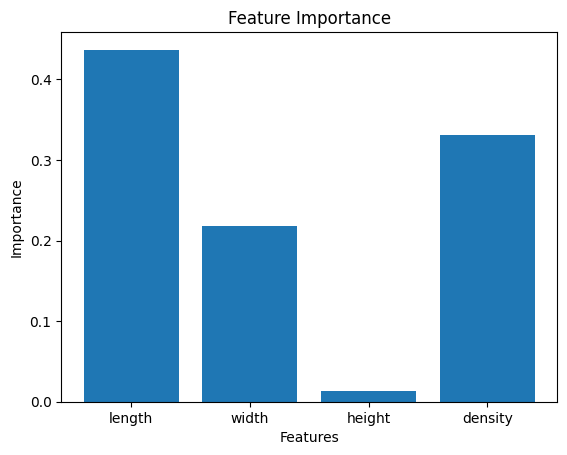


New Object Prediction: vehicle


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [1]:

# LiDAR Obstacle Classification using ML

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler


# STEP 1: SIMULATE LiDAR DATA


np.random.seed(42)

def generate_data(n=150):
    data = []

    for _ in range(n):
        # Vehicles
        data.append([np.random.uniform(3.5, 5.0),
                     np.random.uniform(1.5, 2.2),
                     np.random.uniform(1.2, 2.0),
                     np.random.randint(150, 250),
                     "vehicle"])

        # Pedestrians
        data.append([np.random.uniform(0.3, 0.8),
                     np.random.uniform(0.3, 0.8),
                     np.random.uniform(1.5, 2.0),
                     np.random.randint(20, 60),
                     "pedestrian"])

        # Cyclists
        data.append([np.random.uniform(1.0, 2.5),
                     np.random.uniform(0.5, 1.0),
                     np.random.uniform(1.2, 1.8),
                     np.random.randint(60, 120),
                     "cyclist"])

    return pd.DataFrame(data, columns=["length", "width", "height", "density", "label"])

df = generate_data()

print("\nSample Data:\n", df.head())


# STEP 2: PREPROCESSING


X = df[["length", "width", "height", "density"]]
y = df["label"]

# Normalize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# STEP 3: TRAIN MODEL


model = RandomForestClassifier(n_estimators=150, random_state=42)
model.fit(X_train, y_train)


# STEP 4: TEST MODEL


y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# STEP 5: CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# STEP 6: VISUALIZATION

# Plot feature distribution
plt.figure()
df.groupby("label")["density"].mean().plot(kind='bar')
plt.title("Average Point Density per Class")
plt.xlabel("Obstacle Type")
plt.ylabel("Density")
plt.show()

# STEP 7: FEATURE IMPORTANCE

features = ["length", "width", "height", "density"]
importances = model.feature_importances_

plt.figure()
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()


# STEP 8: PREDICT NEW OBJECT


# Example new LiDAR object
new_object = np.array([[4.2, 1.8, 1.5, 200]])

# Apply same scaling
new_object_scaled = scaler.transform(new_object)

prediction = model.predict(new_object_scaled)

print("\nNew Object Prediction:", prediction[0])